# 04 – Modelli causali grafici


## Riflessioni sulla causalità

Avete mai notato quanto siano bravi a descrivere il cibo gli chef nei video di YouTube? "Fate ridurre la salsa fino a ottenere una consistenza vellutata". Se state imparando a cucinare, non avete idea di cosa significhi. "Datemi solo il tempo di cottura necessario!" 

Con la causalità, è la stessa cosa. 

Immaginate di entrare in un bar e di sentire delle persone discutere di causalità (probabilmente un bar vicino a una facoltà di economia). In tal caso, sentirete spiegare come il reddito come confondente abbia reso difficile identificare l'effetto dell'immigrazione su quel quartiere, costringendoli a utilizzare una variabile strumentale. A questo punto, potreste non capire di cosa stiano parlando. Ma cercherò di chiarire almeno in parte questo problema.

I **modelli grafici sono il linguaggio della causalità**. Non sono solo uno strumento per dialogare con altri appassionati di causalità, ma anche per rendere più trasparenti i vostri pensieri.

Come punto di partenza, prendiamo ad esempio l'indipendenza condizionale dei potenziali risultati. Questa è una delle principali ipotesi che dobbiamo considerare vere quando effettuiamo un'inferenza causale:

$
(Y_0, Y_1) \perp T | x
$

L'indipendenza condizionale ci permette di misurare un effetto sul risultato dovuto esclusivamente al trattamento e non ad altre variabili confondenti. L'esempio classico è l'**effetto di un farmaco su un paziente malato**. 

Se il farmaco viene somministrato solo ai pazienti gravemente malati, potrebbe addirittura sembrare che la somministrazione del farmaco peggiori le loro condizioni di salute. Questo perché l'**effetto della gravità della malattia si confonde con l'effetto del farmaco**. Se suddividiamo i pazienti in casi gravi e non gravi e analizziamo l'impatto del farmaco in ciascun sottogruppo, otterremo un quadro più chiaro dell'effetto attuale. Questa **suddivisione della popolazione** in base alle sue caratteristiche è ciò che chiamiamo **controllo o condizionamento su X**. Condizionando sui casi gravi, il meccanismo di trattamento diventa praticamente casuale. I pazienti del gruppo con malattia grave potrebbero ricevere o meno il farmaco solo per caso, non più in base alla gravità della patologia, dato che tutti i pazienti sono uguali sotto questo aspetto. Inoltre, se il trattamento viene assegnato in modo casuale all'interno dei gruppi, diventa condizionatamente indipendente dai potenziali esiti.

L'**indipendenza** e l'**indipendenza condizionata** sono fondamentali per l'inferenza causale. Tuttavia, può essere piuttosto difficile comprenderle appieno. Ma questo può cambiare se utilizziamo il linguaggio corretto per descrivere il problema. È qui che entrano in gioco i **modelli grafici causali**. Un modello grafico causale è un modo per rappresentare il funzionamento della causalità in termini di cosa causa cosa.

Un modello grafico si presenta così:

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import graphviz as gr
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
style.use("fivethirtyeight")

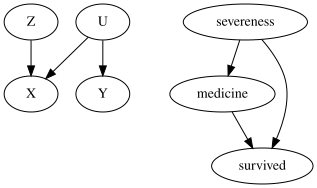

In [3]:
g = gr.Digraph()
g.edge("Z", "X")
g.edge("U", "X")
g.edge("U", "Y")

g.edge("medicine", "survived")
g.edge("severeness", "survived")
g.edge("severeness", "medicine")

g

Ogni nodo rappresenta una variabile casuale. Usiamo frecce, o archi, per indicare **se una variabile ne causa un'altra** [n.d.t se il cambio di una variabile è causa del cambio di un'altra variabile]. Nel primo modello grafico qui sopra, stiamo dicendo che **Z causa X** e che U causa X e Y. Per fornire un esempio più concreto, possiamo tradurre il nostro pensiero sull'impatto del farmaco sulla sopravvivenza del paziente nel secondo grafico qui sopra. La gravità della malattia causa sia la somministrazione del farmaco che la sopravvivenza, e il farmaco a sua volta causa la sopravvivenza. Come vedremo, questo linguaggio dei modelli grafici causali ci aiuterà a rendere più chiaro il nostro pensiero sulla causalità, poiché chiarisce le nostre convinzioni su come funziona il mondo.


## Corso intensivo sui modelli grafici

Esistono [interi semestri sui modelli grafici](https://www.coursera.org/specializations/probabilistic-graphical-models). Ma, ai nostri fini, è (molto) importante comprendere quali tipi di **ipotesi di indipendenza e indipendenza condizionata** un modello grafico implica. Come vedremo, l'indipendenza scorre attraverso un modello grafico come l'acqua scorre in un ruscello. Possiamo interrompere o favorire questo flusso, a seconda di come trattiamo le variabili che lo compongono. Per comprenderlo, esaminiamo alcune strutture grafiche ed esempi comuni. Saranno piuttosto semplici, ma sufficienti per comprendere appieno l'indipendenza e l'indipendenza condizionale nei modelli grafici.




# Catena (Chain)

Innanzitutto, osserviamo questo grafico molto semplice. A causa B, B causa C. Oppure X causa Y che causa Z.


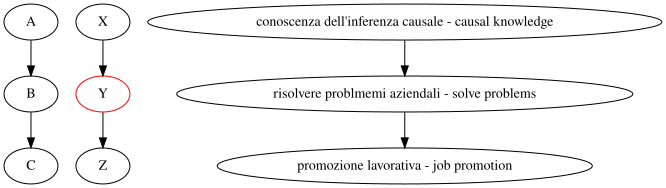

In [4]:
g = gr.Digraph()
g.edge("A", "B")
g.edge("B", "C")

g.edge("X", "Y")
g.edge("Y", "Z")
g.node("Y", "Y", color="red")


g.edge("conoscenza dell'inferenza causale - causal knowledge", "risolvere problmemi aziendali - solve problems")
g.edge("risolvere problmemi aziendali - solve problems", "promozione lavorativa - job promotion")

g

Nel primo grafico, la dipendenza scorre nella direzione delle frecce [n.d.t. se A -> B vuol dire che B dipende da A]. Si noti che la dipendenza è simmetrica, sebbene sia un po' meno intuitiva. [n.d.t. questo DAG mi dice anche che "Se vedo che hai ottenuto una promozione (Z), posso "scommettere" che tu sia bravo a risolvere problemi (Y) e che, probabilmente, tu conosca l'inferenza causale (X)".]

Per fare un esempio più concreto, supponiamo che la conoscenza dell'inferenza causale sia l'unico modo per risolvere i problemi aziendali, e risolvere tali problemi sia l'unico modo per ottenere una promozione. Quindi la conoscenza causale implica la risoluzione di problemi che portano a una promozione. **Possiamo affermare che la promozione dipende dalla conoscenza causale**. Maggiore è la competenza causale, maggiori sono le probabilità di ottenere una promozione. Allo stesso modo, maggiori sono le probabilità di promozione, maggiori sono le probabilità di possedere la conoscenza causale. Altrimenti, sarebbe difficile ottenere una promozione.

Ora, supponiamo di **condizionare sulla variabile intermedia**. In questo caso, la dipendenza è bloccata. Quindi, **X e Z sono indipendenti dato Y**. Nel grafico sopra, il **rosso indica che Y è una variabile condizionata**. Allo stesso modo, nel nostro esempio, **se so che sei bravo a risolvere i problemi, sapere che conosci l'inferenza causale non mi fornisce ulteriori informazioni sulle tue possibilità di ottenere una promozione**. In termini matematici, 

$E[Promozione|Risoluzione \ dei \ problemi, Conoscenza \ causale]=E[Promozione|Risoluzione \ dei \ problemi]$

[n.d.t   E[Z∣Y,X]=E[Z∣Y]     Traduzione della formula: "L'aspettativa di ottenere la promozione (Z), sapendo sia che risolvi i problemi (Y) sia che conosci la teoria (X), è esattamente uguale all'aspettativa di averla sapendo solo che risolvi i problemi (Y)."   La **X** è diventata **inutile ai fini della previsione** una volta che Y è noto.]


Anche l'inverso è vero: una volta che so quanto sei bravo a risolvere i problemi, sapere del tuo stato di promozione non mi fornisce ulteriori informazioni sulla probabilità che tu conosca l'inferenza causale.

Come regola generale, **il flusso di dipendenza nel percorso diretto da A a C viene bloccato quando condizioniamo su una variabile intermedia B**. Ovvero,


$A \not \perp C$             

[n.d.t. A dipende da C]

e

$
A \perp C | b
$

[n.d.t. A NON dipende da C, dato b]


# Biforcazioni (Fork)

Ora, consideriamo una struttura a biforcazione. La **stessa variabile causa altre due** variabili lungo il grafico. In questo caso, la dipendenza scorre all'indietro attraverso le frecce e abbiamo un **percorso di ritorno**. Possiamo chiudere la via secondaria e neutralizzare la dipendenza condizionando sulla causa comune.

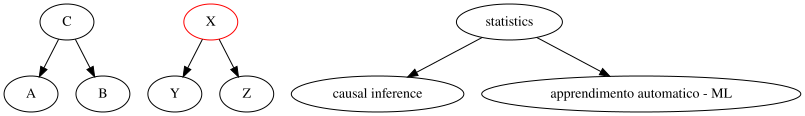

In [5]:
g = gr.Digraph()
g.edge("C", "A")
g.edge("C", "B")

g.edge("X", "Y")
g.edge("X", "Z")
g.node("X", "X", color="red")

g.edge("statistics", "causal inference")
g.edge("statistics", "apprendimento automatico - ML")

g

Ad esempio, supponiamo che la tua conoscenza della statistica ti porti ad avere una maggiore conoscenza dell'inferenza causale e dell'apprendimento automatico. Se non conosco il tuo livello di conoscenza statistica, sapere che sei bravo nell'inferenza causale rende più probabile che tu sia bravo anche nell'apprendimento automatico. Questo perché, anche se non conosco il tuo livello di conoscenza statistica, posso dedurlo dalla tua conoscenza dell'inferenza causale. Se sei bravo nell'inferenza causale, probabilmente sei bravo anche in statistica, il che rende più probabile che tu sia bravo anche nell'apprendimento automatico.

Ora, se considero la tua conoscenza della statistica come un parametro di riferimento, la tua conoscenza dell'apprendimento automatico diventa indipendente dalla tua conoscenza dell'inferenza causale. Conoscere il tuo livello di statistica mi fornisce già tutte le informazioni necessarie per dedurre il tuo livello di competenza nell'apprendimento automatico. Come vedi, conoscere il tuo livello di inferenza causale non fornisce ulteriori informazioni in questo caso.

Come regola generale, due variabili che **condividono una causa comune sono dipendenti**, ma indipendenti quando consideriamo la causa comune come un parametro di riferimento. Oppure

$A \not \perp B$

e

$
A \perp B | c
$


## Collider


L'unica struttura mancante è il collider. Un collider si verifica quando **due frecce si scontrano su una singola variabile**. 


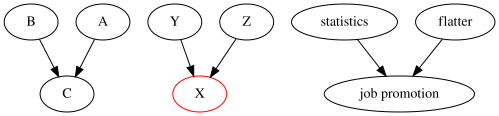

In [6]:
g = gr.Digraph()
g.edge("B", "C")
g.edge("A", "C")

g.edge("Y", "X")
g.edge("Z", "X")
g.node("X", "X", color="red")

g.edge("statistics", "job promotion")
g.edge("flatter", "job promotion")

g

Ad esempio, consideriamo due modi per ottenere una promozione sul lavoro: essere bravi in ​​statistica o adulare il proprio capo. Se non considero la promozione come un dato di fatto, ovvero se non so se la otterrete o meno, allora il vostro livello di competenza in statistica e la vostra capacità di adulare il capo sono indipendenti. In altre parole, sapere quanto siete bravi in ​​statistica non mi dice nulla sulla vostra abilità nell'adulare il capo. D'altra parte, se otteneste una promozione, improvvisamente, conoscere il vostro livello di competenza in statistica mi direbbe qualcosa sulla vostra capacità di adulare. Se siete scarsi in statistica e ottenete una promozione, probabilmente saprete come adulare. Altrimenti, non la otterreste. Viceversa, se siete scarsi nell'adulare, ne consegue che siete bravi in ​​statistica. Questo fenomeno viene talvolta definito **spiegazione dell'effetto**, perché una causa spiega già l'effetto, rendendo l'altra causa meno probabile.

Come regola generale, condizionare su una variabile di collisione apre il percorso di dipendenza. Non condizionare su di essa lo lascia chiuso. Oppure

$A \perp B$

e

$
A \not \perp B | c
$


## Riassunto fino a qua 

### Percorsi Aperti 

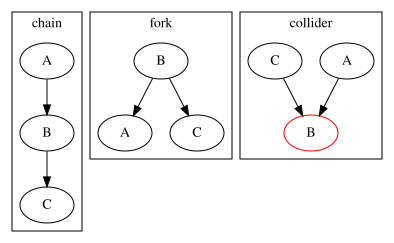

In [7]:
g = gr.Digraph()

with g.subgraph(name="cluster_chain") as c:
    c.attr(label="chain")
    c.edge("A_", "B_")
    c.edge("B_", "C_")
    g.node("A_", "A")
    g.node("B_", "B")
    g.node("C_", "C")
    


with g.subgraph(name="cluster_fork") as c:
    c.attr(label="fork")
    c.edge("_B", "_A")
    c.edge("_B", "_C")
    g.node("_A", "A")
    g.node("_C", "C")
    c.node("_B", "B")
    

with g.subgraph(name="cluster_collider") as c:
    c.attr(label="collider")
    c.edge("_A_", "_B_")
    c.edge("_C_", "_B_")
    g.node("_A_", "A")
    g.node("_C_", "C")
    c.node("_B_", "B", color="red")

g

Questi sono **percorsi aperti**, in cui **A e C sono dipendenti**.

### Percorsi chiusi

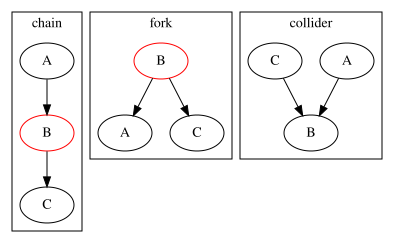

In [8]:
g = gr.Digraph()

with g.subgraph(name="cluster_chain") as c:
    c.attr(label="chain")
    c.edge("A_", "B_")
    c.edge("B_", "C_")
    g.node("A_", "A")
    g.node("B_", "B", color="red")
    g.node("C_", "C")
    


with g.subgraph(name="cluster_fork") as c:
    c.attr(label="fork")
    c.edge("_B", "_A")
    c.edge("_B", "_C")
    g.node("_A", "A")
    g.node("_C", "C")
    c.node("_B", "B", color="red")
    

with g.subgraph(name="cluster_collider") as c:
    c.attr(label="collider")
    c.edge("_A_", "_B_")
    c.edge("_C_", "_B_")
    g.node("_A_", "A")
    g.node("_C_", "C")
    c.node("_B_", "B")

g

Questi sono **percorsi chiusi** o **bloccati**, in cui **A e C sono indipendenti**.

## Strutture complesse


Conoscendo le tre strutture, possiamo derivare una regola ancora più generale. Un percorso è bloccato se e solo se:
1. Contiene un non collider che è stato condizionato
2. Contiene un collider che non è stato condizionato e non ha discendenti che sono stati condizionati.


[n.d.t. che un percorso sia **bloccato significa che 2 variabili sono indipendenti**, dato il percorso. Pensa alla dipendenza statistica come a un liquido (o corrente elettrica) che scorre lungo le frecce del grafo. Se il "flusso" passa da A a C, significa che A e C sono correlati (sapere qualcosa su A ti aiuta a prevedere C).]



Ecco un **promemoria su come fluisce la dipendenza** in un grafo. L'ho preso da una [presentazione di Stanford](http://ai.stanford.edu/~paskin/gm-short-course/lec2.pdf) di Mark Paskin. Le frecce con **linee alle estremità indicano indipendenza**, mentre le frecce senza linee alle estremità indicano dipendenza.

![img](data/img/graph-flow.png)

[n.d.t  nell'immagine sopra sono nell'ordine:

| **Chain** | **Fork** | **Collider** | 
|----------------------|----------------|-------------|
| aperto               |    aperto         | chiuso|
| chiuso           | chiuso            | aperto|

]

### Esercizio 

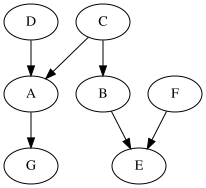

In [9]:
g = gr.Digraph()
g.edge("C", "A")
g.edge("C", "B")
g.edge("D", "A")
g.edge("B", "E")
g.edge("F", "E")
g.edge("A", "G")

g

Come ultimo esempio, provate a individuare alcune relazioni di indipendenza e dipendenza nel seguente grafo causale.

1. $D \perp C$?

2. $D \perp C| A $?

3. $D \perp C| G $?

4. $A \perp F $?

5. $A \perp F|E $?

6. $A \perp F|E,C $?

**Risposte**:

1. $D \perp C$. Contiene un collider su cui **non** è stato condizionato.

2. $D \not\perp C| A $. Contiene un collider su cui è stato condizionato.

3. $D \not\perp C| G$. Contiene il discendente di un collider su cui è stato condizionato. Si può vedere G come una sorta di proxy per A in questo caso.

4. $A \perp F $. Contiene un collider, B->E<-F, su cui **non** è stato condizionato.

5. $A \not\perp F|E $. Contiene un collider, B->E<-F, su cui è stato condizionato.

6. $A \perp F|E, C $. Contiene un collider, B->E<-F, su cui è stato condizionato, ma contiene anche un non collider su cui è stato condizionato. Il condizionamento su E apre il percorso, ma il condizionamento su C lo richiude.

La conoscenza dei modelli grafici causali ci permette di comprendere i problemi che sorgono nell'inferenza causale. Come abbiamo visto, il problema si riduce sempre al bias.

$
E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATET} + \underbrace{\{ E[Y_0|T=1] - E[Y_0|T=0] \}}_{BIAS}
$

I modelli grafici ci permettono di diagnosticare quale bias stiamo affrontando e quali strumenti ci servono per correggerlo.


## Bias da confondimento -  Storture Confondenti (Confounding Bias)  




![img](./data/img/causal-graph/both_crap.png)

La prima causa significativa di bias è il **confondimento**. 

Si verifica quando il trattamento e l'esito condividono una causa comune. Ad esempio, supponiamo che il trattamento sia l'istruzione e l'esito sia il reddito. È difficile stabilire l'effetto causale dell'istruzione sui salari perché entrambi condividono una causa comune: l'intelligenza. Quindi potremmo sostenere che le persone più istruite guadagnano di più semplicemente perché sono più intelligenti, non perché hanno un livello di istruzione più elevato. Dobbiamo **eliminare tutti i percorsi indiretti** tra il trattamento e l'esito per identificare l'effetto causale. In tal caso, l'unico effetto che rimarrà sarà l'effetto diretto T->Y. Nel nostro esempio, se controlliamo per l'intelligenza, ovvero confrontiamo persone con lo stesso livello di intelletto ma con diversi livelli di istruzione, la differenza nell'esito sarà dovuta solo alla differenza di istruzione, poiché l'intelligenza sarà la stessa per tutti. **Per correggere il bias di confondimento, dobbiamo controllare tutte le cause comuni** del trattamento e dell'esito.

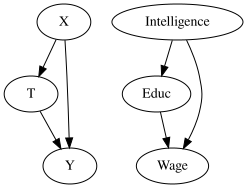

In [10]:
g = gr.Digraph()
g.edge("X", "T")
g.edge("X", "Y")
g.edge("T", "Y")

g.edge("Intelligence", "Educ"),
g.edge("Intelligence", "Wage"),
g.edge("Educ", "Wage")
g

Purtroppo, **non** è **sempre possibile controllare tutte le cause comuni**. A volte, ci sono cause sconosciute o cause note che non possiamo misurare. Il caso dell'intelligenza rientra in quest'ultima categoria. Nonostante tutti gli sforzi, gli scienziati non sono ancora riusciti a misurare l'intelligenza in modo preciso. Userò la lettera **U per indicare le variabili non misurabili**. Ora, supponiamo per un momento che l'intelligenza non possa influenzare direttamente il tuo percorso scolastico. Influisce sul tuo punteggio nei test ENEM - SAT, ma i test ENEM - SAT determinano il tuo livello di istruzione, poiché aprono la strada all'ammissione a una buona università. Anche se non possiamo controllare l'intelligenza, che non è misurabile, possiamo controllare il punteggio dei test SAT e chiudere questa via d'accesso indiretta.

Unfortunately, it is not always possible to control all common causes. Sometimes, there are unknown causes or known causes that we can't measure. The case of intelligence is one of the latter. Despite all the effort, scientists haven't yet figured out how to measure intelligence well. I'll use U to denote unmeasured variables here. Now, assume for a moment that intelligence can't affect your education directly. It affects how well you do on the SATs, but the SATs determine your level of schooling since it opens the possibility of a good college. Even if we can't control for the unmeasurable intelligence, we can control for SAT and close that backdoor path.

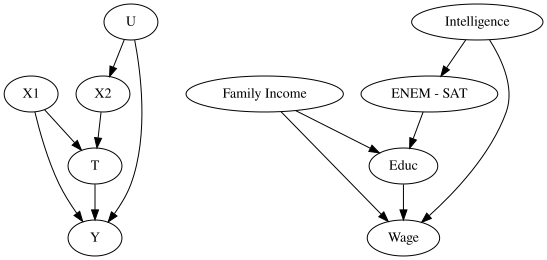

In [11]:
g = gr.Digraph()
g.edge("X1", "T")
g.edge("T", "Y")
g.edge("X2", "T")
g.edge("X1", "Y")
g.edge("U", "X2")
g.edge("U", "Y")

g.edge("Family Income", "Educ")
g.edge("Educ", "Wage")
g.edge("ENEM - SAT", "Educ")
g.edge("Family Income", "Wage")
g.edge("Intelligence", "ENEM - SAT")
g.edge("Intelligence", "Wage")
g

Nel grafico qui sopra, condizionare su X1 e X2, ovvero sul punteggio SAT e sul reddito familiare, è sufficiente a chiudere tutti i percorsi di interferenza tra il trattamento e l'esito. In altre parole, $(Y_0, Y_1) \perp T | X1, X2$. Quindi, anche se non possiamo misurare tutte le cause comuni, possiamo comunque ottenere l'indipendenza condizionale se controlliamo le variabili misurabili che mediano l'effetto delle variabili non misurate sul trattamento. Una breve nota: abbiamo anche $(Y_0, Y_1) \perp T | X1, U$, ma poiché non possiamo osservare U, non possiamo condizionare su di essa.

Ma cosa succede se non è così? Cosa succede se la variabile non misurata causa direttamente il trattamento e l'esito? Nell'esempio seguente, l'intelligenza causa ora l'istruzione e il reddito. Quindi c'è un confondimento nella relazione tra il trattamento (istruzione) e l'esito (salario). In questo caso, non possiamo controllare il confonditore perché non è misurabile. Tuttavia, disponiamo di altre variabili misurabili che possono fungere da proxy per il fattore confondente. Queste variabili non sono direttamente coinvolte nel processo di distorsione, ma il loro controllo contribuirà a ridurne l'entità (pur non eliminandola completamente). Tali variabili sono talvolta definite fattori confondenti surrogati.

Nel nostro esempio, non possiamo misurare l'intelligenza, ma possiamo misurarne alcune cause, come il livello di istruzione del padre e della madre, e alcuni dei suoi effetti, come il QI o il punteggio SAT. Il controllo di queste variabili surrogate non è sufficiente a eliminare la distorsione, ma contribuisce a ridurla.

In the following graph, conditioning on X1 and X2, or SAT and family income, is sufficient to close all backdoor paths between the treatment and the outcome. In other words, $(Y_0, Y_1) \perp T | X1, X2$. So even if we can't measure all common causes, we can still attain conditional independence if we control for measurable variables that mediate the effect of the unmeasured on the treatment. One quick note, we also have $(Y_0, Y_1) \perp T | X1, U$, but since we can't observe U, we can't condition on it. 

But what if that is not the case? What if the unmeasured variable causes the treatment and the outcome directly? In the following example, intelligence causes education and income now. So there is confounding in the relationship between the treatment education and the outcome wage. In this case, we can't control the confounder because it is unmeasurable. However, we have other measured variables that can act as a proxy for the confounder. Those variables are not in the backdoor path, but controlling for them will help lower the bias (but it won't eliminate it). Those variables are sometimes referred to as surrogate confounders.

In our example, we can't measure intelligence, but we can measure some of its causes, like the father's and mother's education, and some of its effects, like IQ or SAT score. Controlling for those surrogate variables is not sufficient to eliminate bias, but it helps.

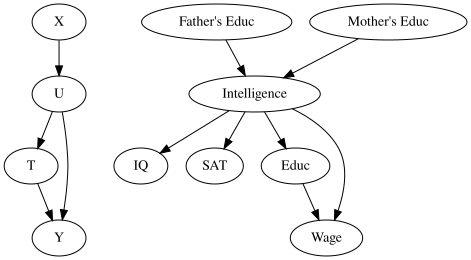

In [12]:
g = gr.Digraph()
g.edge("X", "U")
g.edge("U", "T")
g.edge("T", "Y")
g.edge("U", "Y")

g.edge("Intelligence", "IQ")
g.edge("Intelligence", "SAT")
g.edge("Father's Educ", "Intelligence")
g.edge("Mother's Educ", "Intelligence")

g.edge("Intelligence", "Educ")
g.edge("Educ", "Wage")
g.edge("Intelligence", "Wage")

g

## Selection Bias

You might think it is a good idea to add everything you can measure to your model just to ensure you don't have confounding bias. Well, think again.

![image.png](./data/img/causal-graph/selection_bias.png)

The second significant source of bias is what we will call selection bias. Here, I think the distinction between it and confounding bias is constructive, so I'll stick to it. If confounding bias happens when we don't control for a common cause, selection bias is more related to effects. One word of caution here, economists tend to refer to all sorts of biases as selection bias. 

Often, selection bias arises when we control for more variables than we should. It might be the case that the treatment and the potential outcome are marginally independent but become dependent once we condition on a collider. 

Imagine that with the help of some miracle, you can finally randomize education to measure its effect on wages. But just to be sure you won't have confounding, you control for many variables. Among them, you control for investments. But investment is not a common cause of education and wage. Instead, it is a consequence of both. More educated people both earn more and invest more. Also, those who make more invest more. Since investment is a collider, by conditioning on it, you are opening a second path between the treatment and the outcome, which will make it harder to measure the direct effect. One way to think about this is that by controlling investments, you look at small groups of the population where investment is the same and then find the effect of education on those groups. But by doing so, you are also indirectly and inadvertently not allowing wages to change much. As a result, you won't be able to see how education changes wages because you are not allowing wages to change as they should. 

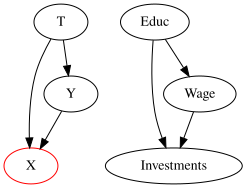

In [13]:
g = gr.Digraph()
g.edge("T", "X")
g.edge("T", "Y")
g.edge("Y", "X")
g.node("X", "X", color="red")

g.edge("Educ", "Investments")
g.edge("Educ", "Wage")
g.edge("Wage", "Investments")

g

Imagine that investments and education take only 2 values to demonstrate why this is the case. Whether people invest or not. They are either educated or not. Initially, when we don't control for investments, the bias term is zero: $E[Y_0|T=1] - E[Y_0|T=0] = 0$ because the education was randomised. This means that the wage people would have if they didn't receive education $Wage_0$ is the same if they do or don't receive the education treatment. But what happens if we condition on investments?

Looking at those who invest, we probably have the case that $E[Y_0|T=0, I=1] > E[Y_0|T=1, I=1]$. In words, among those who invest, the ones who manage to do so even without education are more likely to achieve high earnings, regardless of their education level. For this reason, the wage those people have, $Wage_0|T=0$, is probably higher than the wage the educated group would have if they didn't have education, $Wage_0|T=1$. A similar reasoning can be applied to those who don't invest, where we also probably have $E[Y_0|T=0, I=0] > E[Y_0|T=1, I=0]$. Those who don't invest even with education probably would have a lower wage, had they not got the education, than those who didn't invest but didn't have an education. 

To use a purely graphical argument, if someone invests, knowing that they have high education explains away the second cause, which is wage. Conditioned on investing, higher education is associated with low wages and we have a negative bias $E[Y_0|T=0, I=i] > E[Y_0|T=1, I=i]$. 

As a side note, all of this we've discussed is true if we condition on any descendent of a common effect.

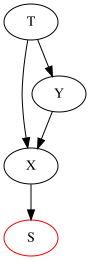

In [14]:
g = gr.Digraph()
g.edge("T", "X")
g.edge("T", "Y")
g.edge("Y", "X")
g.edge("X", "S")
g.node("S", "S", color="red")
g

A similar thing happens when we condition on a mediator of the treatment. A mediator is a variable between the treatment and the outcome. It, well, mediates the causal effect. For example, suppose again you can randomize education. But, just to be sure, you decide to control whether or not the person had a white-collar job. Once again, this conditioning biasses the causal effect estimation. This time, not because it opens a front door path with a collider, but because it closes one of the channels through which the treatment operates. In our example, getting a white-collar job is one way more education leads to higher pay. By controlling it, we close this channel and leave open only the direct effect of education on wages.

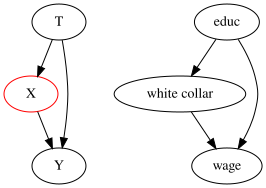

In [15]:
g = gr.Digraph()
g.edge("T", "X")
g.edge("T", "Y")
g.edge("X", "Y")
g.node("X", "X", color="red")

g.edge("educ", "white collar")
g.edge("educ", "wage")
g.edge("white collar", "wage")

g

To give a potential outcome argument, we know that, due to randomisation, the bias is zero $E[Y_0|T=0] - E[Y_0|T=1] = 0$. However, if we condition on the white-collar individuals, we have that $E[Y_0|T=0, WC=1] > E[Y_0|T=1, WC=1]$. That is because those who manage to get a white-collar job even without education are probably more hard-working than those who require the help of education to get the same job. With the same reasoning, $E[Y_0|T=0, WC=0] > E[Y_0|T=1, WC=0]$ because those that didn't get a white-collar job even with an education are probably less hard-working than those that didn't, but also didn't have any education. 

In our case, conditioning on the mediator induces a negative bias. It makes the effect of education seem lower than it actually is. This is the case because the causal effect is positive. If the effect were negative, conditioning on a mediator would have a positive bias. In all cases, this sort of conditioning makes the effect look weaker than it is. 

To put it more prosaic way, suppose that you have to choose between two candidates for a job at your company. Both have equally impressive professional achievements, but one does not have a higher education degree. Which one should you choose? Of course, you should go with the one without the higher education because he managed to achieve the same things as the other one but had the odds stacked against him.

![image.png](./data/img/causal-graph/three_bias.png)


## Key Ideas




We've studied graphical models as a language to better understand and express causality ideas. We did a quick summary of the rules of conditional independence on a graph. This helped us then explore three structures that can lead to bias.

The first was confounding, which happens when treatment and outcome have a common cause that we don't account for or control for. The second is selection bias due to conditioning on a common effect. The third structure is also a form of selection bias, this time due to excessive controlling of mediator variables. This excessive controlling could lead to bias even if the treatment was randomly assigned. Selection bias can often be fixed by simply doing nothing, which is why it is dangerous. Since we are biased toward action, we tend to see ideas that control things as clever when they can be doing more harm than good. 

